In [1]:
import subprocess
import os
import os.path as osp
import numpy as np
from imageio import imwrite
import argparse
from einops import rearrange
import cv2
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from skimage.io import imread


In [2]:
def loading_random_digit(data_dir, digit_label):
    image_class_path = "{}/Digit{}".format(data_dir, digit_label)
    file_names = os.listdir(image_class_path)
    file = random.choice(file_names)
    image_path = "{}/{}".format(image_class_path, file)
    image = cv2.imread(image_path)
    return image

In [3]:
def random_digits(data_dir, digit_labels):
    digits = []
    for i in range(len(digit_labels)):
        image = loading_random_digit(data_dir, digit_labels[i])
        digits.append(image)
    return digits

In [4]:
def finding_bounding_boxes(digit_image, label, xmin_digit): # Values in pixels

    digit_image = digit_image / 255
    digit_image = abs(digit_image - 1)
    non_zero = np.nonzero(digit_image)
    min_values = np.min(non_zero, axis=1) 
    maximal_values = np.max(non_zero, axis=1) 

    width = maximal_values[1] - min_values[1]  # xmax - xmin
    heigth = maximal_values[0] - min_values[0] # ymax - ymin
    xcentre = min_values[1] + width / 2
    ycentre = min_values[0] + heigth / 2

    return [label, xmin_digit+xcentre, ycentre, width, heigth]


In [5]:

# NB! This code is based on this Github repository: https://github.com/shaohua0116/MultiDigitMNIST/tree/master


def font_digits_generator(digits_path, multidigits_path, train_val_test_ratio, digit_size, overlap, num_image_per_class, random_seed):

    # Creating the class split for train, val and test
    rs = np.random.RandomState(random_seed)
    num_class = 10**3 # classes**nr_of_digits
    classes = list(np.array(range(num_class)))
    rs.shuffle(classes)
    
    num_train, num_val, num_test = [
            int(float(ratio)/np.sum(train_val_test_ratio)*num_class)
            for ratio in train_val_test_ratio]
    
    train_classes = classes[:num_train]
    val_classes = classes[num_train:num_train+num_val]
    test_classes = classes[num_train+num_val:]

    image_size = [digit_size, (digit_size-overlap)*2+digit_size] # height, width
    xymin_digits = [[0, 0], [0, digit_size-overlap], [0, (digit_size-overlap)*2]] # digit1_ymin, digit1_xmin, digit2_ymin, ...

    np.random.seed(random_seed)

    if not os.path.exists(multidigits_path):
        os.makedirs(multidigits_path)

    split_classes = [train_classes, val_classes, test_classes]
    count = 1 # Amount of classes that we have generates images for
    
    for i, split_name in enumerate(['train', 'val', 'test']):

        images_path = osp.join(osp.join(multidigits_path, 'images'), split_name)
        labels_path = osp.join(osp.join(multidigits_path, 'labels'), split_name)
        print('Generating images for {} at {}'.format(split_name, images_path))
        
        if not os.path.exists(images_path):
            os.makedirs(images_path)
        if not os.path.exists(labels_path):
            os.makedirs(labels_path)
            
        for j, current_class in enumerate(split_classes[i]):
            class_str = str(current_class)
            class_str = '0'*(3-len(class_str))+class_str
            print('(progress: {}/{})'.format(count, len(classes)))
            
            for k in range(num_image_per_class):

                digit_classes = [int(letter) for letter in class_str]
                digits = random_digits(digits_path, digit_classes)

                multidigit = np.zeros((image_size[0], image_size[1], 3)).astype(float)
                multidigit[xymin_digits[0][0]:xymin_digits[0][0]+digit_size, xymin_digits[0][1]:xymin_digits[0][1]+digit_size] = digits[0]
                multidigit[xymin_digits[1][0]:xymin_digits[1][0]+digit_size, xymin_digits[1][1]:xymin_digits[1][1]+digit_size] = digits[1]
                multidigit[xymin_digits[2][0]:xymin_digits[2][0]+digit_size, xymin_digits[2][1]:xymin_digits[2][1]+digit_size] = digits[2]

                image_bboxes = []
                for i in range(len(digits)):
                    bbox = finding_bounding_boxes(digits[i], digit_classes[i], xymin_digits[i][1])
                    image_bboxes.append(bbox)

                # Saving the image
                image_path = osp.join(images_path, '{}_{}.png'.format(class_str, k))
                Image.fromarray((multidigit).astype(np.uint8)).save(image_path)

                # write the label and bounding boxes
                label_path = osp.join(labels_path, '{}_{}.txt'.format(class_str, k))
                with open(label_path, "w") as file:
                    for label_bbox in image_bboxes:
                        file.write(str(label_bbox[0]) + " " + 
                                   str(label_bbox[1]/image_size[1]) + " " + 
                                   str(label_bbox[2]/image_size[0]) + " " + 
                                   str(label_bbox[3]/image_size[1]) + " " + 
                                   str(label_bbox[4]/image_size[0]) + "\n")
                    file.close()

            count += 1

    print("Image generation is done")

In [ ]:

parent_path = str(Path.cwd().parent)
digits_path = parent_path + "/datasets/Fonts_dataset" # Digits path; 
multidigits_path = parent_path + "/datasets/Fonts_dataset_muliple_generation" # Output path

train_val_test_ratio = [80, 20, 0]
digit_size = 128 
overlap = 16
num_image_per_class = 50
random_seed = 123

font_digits_generator(digits_path, 
                      multidigits_path, 
                      train_val_test_ratio, 
                      digit_size, 
                      overlap, 
                      num_image_per_class, 
                      random_seed)

## Visualization

In [6]:
def reading_in_bbox_txt_file(bbox_path) :
    bboxes = []
    file = open(bbox_path,'r')
    while True:
        content=file.readline()
        if not content:
            break
        elements = [ float(x) for x in content.strip().split(" ") ]
        bboxes.append(elements)
    file.close()

    return bboxes

In [7]:
def show_image_with_bounding_box (xcentre, ycentre, width, heigth, image_width, image_height):

    xmin = (xcentre - width/2) * image_width
    ymin = (ycentre - heigth/2) * image_height
    xmax = (xcentre + width/2) * image_width
    ymax = (ycentre + heigth/2) * image_height

    plt.plot([xmin, xmin], [ymin, ymax], '-', color = 'red' ) # Left edge
    plt.plot([xmax, xmax], [ymin, ymax], '-', color = 'red') # Right edge
    plt.plot([xmin, xmax], [ymin, ymin], '-', color = 'red') # Top edge
    plt.plot([xmin, xmax], [ymax, ymax], '-', color = 'red') # Bottom edge

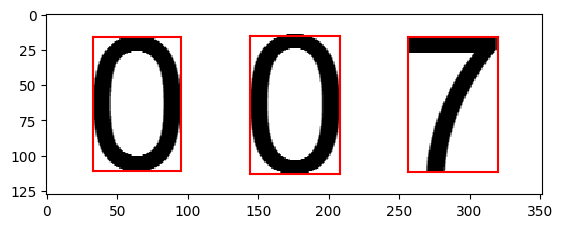

In [8]:

parent_path = str(Path.cwd().parent)
image_path = parent_path + "/datasets/Fonts_dataset_muliple_generation/images/train/007_0.png" # replace with existing file name
label_path = parent_path + "/datasets/Fonts_dataset_muliple_generation/labels/train/007_0.txt" # replace with existing file name

img = imread(image_path)
image_width = img.shape[1]
image_height = img.shape[0]

label_bboxes = reading_in_bbox_txt_file(label_path)

plt.imshow(img, cmap='Greys_r',  interpolation='nearest')

for i in range(len(label_bboxes)):
    show_image_with_bounding_box(label_bboxes[i][1], label_bboxes[i][2], label_bboxes[i][3], label_bboxes[i][4], image_width, image_height)

plt.axis('on')
plt.show()